#Dataset SETUP
#estrazione temporanea su /content

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls -lh /content/drive/MyDrive | grep archive

-rw------- 1 root root  13G Feb 25 17:00 archive.zip


In [ ]:
!df -h /

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  20% /


In [ ]:
cp /content/drive/MyDrive/archive.zip /content/

In [ ]:
ls -lh /content | grep archive

-rw------- 1 root root  13G Mar  4 07:31 archive.zip


In [ ]:
!mkdir -p /content/wikiart_tmp
!unzip -q /content/archive.zip -d /content/wikiart_tmp

In [ ]:
ls /content/wikiart_tmp | head

wikiart/
wikiart_art_pieces.csv


In [ ]:
!find /content/wikiart_tmp -name "*.csv"

/content/wikiart_tmp/wikiart_art_pieces.csv


In [ ]:
!find /content/wikiart_tmp -type d -maxdepth 2 | head -n 20

find: warning: you have specified the global option -maxdepth after the argument -type, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/content/wikiart_tmp
/content/wikiart_tmp/wikiart
/content/wikiart_tmp/wikiart/wikiart


In [ ]:
import pandas as pd

csv_path = "/content/wikiart_tmp/wikiart_art_pieces.csv"
df = pd.read_csv(csv_path)

df.columns

Index(['artist', 'style', 'genre', 'movement', 'tags', 'url', 'img',
       'file_name'],
      dtype='object')

In [ ]:
df.head()

,artist,style,genre,movement,tags,url,img,file_name
0,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch'...",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,0-ravenna-cappella-arcivescovile-166.jpg
1,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,1-ravenna-cappella-arcivescovile-167.jpg
2,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Prophet', 'History']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,2-ravenna-cappella-arcivescovile-168.jpg
3,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Prophet']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,3-ravenna-cappella-arcivescovile-169.jpg
4,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Prophet']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,4-ravenna-cappella-arcivescovile-171.jpg


In [ ]:
# Lista di tutti i generi con frequenza
genre_counts = df["genre"].value_counts(dropna=False)

genre_counts

,count
genre,
portrait,25155
landscape,21692
genre painting,20831
abstract,15341
religious painting,10063
...,...
"religious painting,miniature",1
"icon,sculpture",1
"cityscape,digital",1


In [ ]:
ALLOWED_KEYWORDS = [
    "painting",
    "portrait",
    "landscape",
    "abstract",
    "illustration",
    "fresco",
    "miniature",
    "icon",
    "still life",
    "mythological",
    "history"
]

EXCLUDED_KEYWORDS = [
    "sculpture",
    "photography",
    "installation",
    "architecture",
    "design",
    "performance",
    "object",
    "digital",
    "3d"
]

def is_valid_2d_genre(genre):
    if pd.isna(genre):
        return False
    g = genre.lower()
    if any(bad in g for bad in EXCLUDED_KEYWORDS):
        return False
    if any(ok in g for ok in ALLOWED_KEYWORDS):
        return True
    return False

df_2d = df[df["genre"].apply(is_valid_2d_genre)]

print("Numero opere 2D selezionate:", len(df_2d))


Numero opere 2D selezionate: 129132


In [ ]:
# Conteggio opere per artista
artist_counts = df_2d["artist"].value_counts()

artist_counts.head(20)

,count
artist,
Nicholas Roerich,1282
Pierre-Auguste Renoir,1282
Claude Monet,1078
Pablo Picasso,1057
Vincent van Gogh,1019
Salvador Dali,996
Henri Matisse,873
Gustave Dore,759
Pyotr Konchalovsky,739


In [ ]:
len(artist_counts)

2881

In [ ]:
TOP_N = 100
excluded_top = set(artist_counts.head(TOP_N).index)
print("Artisti esclusi (top):", len(excluded_top))

Artisti esclusi (top): 100


In [ ]:
manual_blacklist = {
    "Claude Monet", "Pablo Picasso", "Vincent van Gogh", "Salvador Dali",
    "Henri Matisse", "Rembrandt", "Leonardo da Vinci", "Michelangelo",
    "Caravaggio", "Raphael", "Edvard Munch"
}

excluded_artists = excluded_top | manual_blacklist
print("Artisti esclusi totali:", len(excluded_artists))

Artisti esclusi totali: 105


In [ ]:
df_anon = df_2d[~df_2d["artist"].isin(excluded_artists)]

print("Opere rimaste:", len(df_anon))
print("Artisti rimasti:", df_anon["artist"].nunique())

Opere rimaste: 90138
Artisti rimasti: 2776


tolgo artisti con più di 100 opere

In [ ]:
# df_anon è il dataset già filtrato (90196 opere, 2777 artisti)

artist_counts = df_anon["artist"].value_counts()

valid_artists = artist_counts[artist_counts <= 100].index

df_filtered = df_anon[df_anon["artist"].isin(valid_artists)].copy()

print("Opere prima:", len(df_anon))
print("Artisti prima:", df_anon["artist"].nunique())

print("Opere dopo filtro <=100:", len(df_filtered))
print("Artisti dopo filtro:", df_filtered["artist"].nunique())

Opere prima: 90138
Artisti prima: 2776
Opere dopo filtro <=100: 67853
Artisti dopo filtro: 2612


In [ ]:
!pip -q install -U google-genai pillow

import os
from getpass import getpass

os.environ["GEMINI_API_KEY"] = getpass("Incolla Gemini API key:")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 68.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
Incolla Gemini API key:··········


In [ ]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print("Gemini client pronto")

Gemini client pronto


In [ ]:
SEED = 42

N_LIMIT = 67854

# dataset completo (tutte le opere filtrate)
full_df = df_filtered.reset_index(drop=True).copy()

# randomizzo l'ordine per non analizzare tutte dello stesso artista/movimento di fila
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

run_df = full_df if not N_LIMIT else full_df.head(N_LIMIT)

print("Totale opere disponibili:", len(full_df))
print("Opere in questa run:", len(run_df))

run_df[["artist", "file_name", "img"]].head()

Totale opere disponibili: 67853
Opere in questa run: 67853


,artist,file_name,img
0,Frank W. Benson,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...
1,Manuela Sambo,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...
2,Walter Battiss,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...
3,Alexander Clarot,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...
4,Jean-Baptiste van Loo,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...


In [ ]:
import requests

# Sessione HTTP riutilizzabile
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def fetch_image_bytes(url: str, timeout: int = 20) -> bytes:
    r = session.get(url, timeout=timeout)
    r.raise_for_status()
    return r.content

In [ ]:
import os, json

out_jsonl = "gemini_identification_full.jsonl"

def get_done_urls(jsonl_path):
    done = set()
    if not os.path.exists(jsonl_path):
        return done
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                #URL come chiave univoca
                done.add(rec.get("img_url"))
            except:
                pass
    return done

done_urls = get_done_urls(out_jsonl)
print("File output:", out_jsonl)
print("Già analizzate (ripresa automatica):", len(done_urls))

File output: gemini_identification_full.jsonl
Già analizzate (ripresa automatica): 67847


In [ ]:
import json
import time
import random
from datetime import datetime
from google.genai import types

# Prompt
PROMPT = """Analyze the image.

Can you identify this artwork as a specific known work?

If YES, provide the artist name and artwork title.
If NO, say it is not identified.

Return ONLY this JSON:
{
  "identified": true | false,
  "artist_name": "artist name or null",
  "artwork_title": "artwork title or null"
}

Rules:
- Answer YES only if you believe this is a specific known artwork.
- If unsure, answer NO.
- Do not provide any additional description or explanation.
"""

MODEL_NAME = "models/gemini-2.5-flash"

# RPM
RPM_TARGET = 180
MIN_SECONDS_BETWEEN_CALLS = 0.4

print("MODEL:", MODEL_NAME)
print("RPM_TARGET:", RPM_TARGET)
print("MIN_SECONDS_BETWEEN_CALLS:", MIN_SECONDS_BETWEEN_CALLS)

def guess_mime_type(url: str) -> str:
    u = url.lower()
    if u.endswith(".png"):
        return "image/png"
    if u.endswith(".webp"):
        return "image/webp"
    return "image/jpeg"

def safe_json(text):
    """Prova a parsare JSON anche se il modello mette ```json ... ```"""
    import re
    s = str(text).strip()
    s = re.sub(r"^```(?:json)?\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    try:
        return json.loads(s)
    except:
        try:
            return json.loads(s.replace('""', '"'))
        except:
            return None

def generate_with_retry(prompt: str, img_bytes: bytes, mime: str, max_retries: int = 6):
    """Retry per 503/429 con backoff."""
    image_part = types.Part.from_bytes(data=img_bytes, mime_type=mime)

    for attempt in range(max_retries):
        try:
            resp = client.models.generate_content(
                model=MODEL_NAME,
                contents=[prompt, image_part],
            )
            text = resp.text if hasattr(resp, "text") else str(resp)
            return True, text, None

        except Exception as e:
            msg = repr(e)

            is_503 = ("503" in msg) or ("UNAVAILABLE" in msg) or ("overloaded" in msg.lower())
            is_429 = ("429" in msg) or ("RESOURCE_EXHAUSTED" in msg) or ("quota" in msg.lower())

            if not (is_503 or is_429):
                return False, None, msg

            # backoff + jitter
            wait = MIN_SECONDS_BETWEEN_CALLS * (2 ** min(attempt, 3))
            wait = min(wait, 120) + random.uniform(0, 2)
            print(f"Retry {attempt+1}/{max_retries} tra {wait:.1f}s | errore: {msg[:140]}")
            time.sleep(wait)

    return False, None, f"Max retries reached. Last error: {msg}"

# LOOP
last_call_time = 0
new_done = 0

for idx, row in run_df.iterrows():
    true_artist = row["artist"]
    file_name = row["file_name"]
    img_url = row["img"]


    if img_url in done_urls:
        continue

    record = {
        "i": int(idx),
        "true_artist": true_artist,
        "file_name": file_name,
        "img_url": img_url,
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "model": MODEL_NAME,
        "ok": False,
        "error": None,
        "response_text": None,
        # campi parsati:
        "identified": None,
        "pred_artist": None,
        "pred_title": None,
    }

    # Rate limit spacing
    elapsed = time.time() - last_call_time
    if elapsed < MIN_SECONDS_BETWEEN_CALLS:
        time.sleep(MIN_SECONDS_BETWEEN_CALLS - elapsed + random.uniform(0, 0.2))

    try:
        img_bytes = fetch_image_bytes(img_url)
        mime = guess_mime_type(img_url)

        ok, text, err = generate_with_retry(PROMPT, img_bytes, mime)
        record["ok"] = ok
        record["response_text"] = text
        record["error"] = err

        if ok and text:
            data = safe_json(text)
            if data is None:
                record["ok"] = False
                record["error"] = "JSON parse failed"
            else:
                record["identified"] = data.get("identified")
                record["pred_artist"] = data.get("artist_name")
                record["pred_title"] = data.get("artwork_title")

    except Exception as e:
        record["error"] = repr(e)

    last_call_time = time.time()

    with open(out_jsonl, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

    done_urls.add(img_url)
    new_done += 1

    if new_done % 10 == 0:
        print(f"+{new_done} nuove | ok={record['ok']} | {true_artist} | {file_name}")

print("FINITO RUN. Nuove analizzate:", new_done)
print("Output:", out_jsonl)

MODEL: models/gemini-2.5-flash
RPM_TARGET: 180
MIN_SECONDS_BETWEEN_CALLS: 0.4
FINITO RUN. Nuove analizzate: 0
Output: gemini_identification_full.jsonl


In [ ]:
import pandas as pd
import json

rows = []
with open(out_jsonl, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df_out = pd.DataFrame(rows)
df_out.to_csv("gemini_identification_full.csv", index=False)

df_out[["true_artist", "pred_artist", "identified", "ok", "error"]].tail(10)

,true_artist,pred_artist,identified,ok,error
69636,Qi Baishi,Qi Baishi,True,True,None
69637,Artuš Scheiner,Ivan Bilibin,True,True,None
69638,Oswald Achenbach,Oswald Achenbach,True,True,None
69639,Vasan Sitthiket,Vasan Sitthiket,True,True,None
69640,Pavel Filonov,Umberto Boccioni,True,True,None
69641,Martin Benka,Václav Šimek,True,True,None
69642,Jan Lievens,Rembrandt van Rijn,True,True,None
69643,Jimmy Ernst,Jean Degottex,True,True,None
69644,Il Sassetta (Stefano di Giovanni),Puccio di Simone,True,True,None
69645,Hans Gude,Hans Egger,True,True,None


In [ ]:
import pandas as pd
import unicodedata

# Carica file
df = pd.read_csv("gemini_identification_full.csv")

print("Righe originali:", len(df))

# Rimuovo duplicati per immagine
df = df.drop_duplicates(subset=["img_url"])

print("Righe dopo rimozione duplicati:", len(df))

# Funzione per normalizzare stringhe
def normalize(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    return text

# Estrazione cognome
def extract_surname(name):
    name = normalize(name)
    parts = name.split()
    if len(parts) == 0:
        return ""
    return parts[-1]

df["true_surname"] = df["true_artist"].apply(extract_surname)
df["pred_surname"] = df["pred_artist"].apply(extract_surname)

# Calcoli

total = len(df)

not_identified = (df["identified"] == False).sum()

correct_artist = (
    (df["identified"] == True) &
    (df["true_surname"] == df["pred_surname"])
).sum()

wrong_artist = (
    (df["identified"] == True) &
    (df["true_surname"] != df["pred_surname"])
).sum()

# Percentuali

print("\nTOTALE OPERE:", total)

print("\nNON IDENTIFICATE:",
      not_identified,
      f"({not_identified/total*100:.2f}%)")

print("IDENTIFICATE CORRETTE (cognome match):",
      correct_artist,
      f"({correct_artist/total*100:.2f}%)")

print("IDENTIFICATE MA ARTISTA SBAGLIATO:",
      wrong_artist,
      f"({wrong_artist/total*100:.2f}%)")

Righe originali: 69646
Righe dopo rimozione duplicati: 67847

TOTALE OPERE: 67847

NON IDENTIFICATE: 1280 (1.89%)
IDENTIFICATE CORRETTE (cognome match): 13995 (20.63%)
IDENTIFICATE MA ARTISTA SBAGLIATO: 51403 (75.76%)


In [ ]:
correct_cases = df[
    (df["identified"] == True) &
    (df["true_surname"] == df["pred_surname"])
]

ambiguous_correct = correct_cases[
    correct_cases["true_surname"].isin(ambiguous_list)
]

print("Casi corretti con cognome ambiguo:", len(ambiguous_correct))

Casi corretti con cognome ambiguo: 2212


In [ ]:
import pandas as pd
import unicodedata

df = pd.read_csv("gemini_identification_full.csv")

# Dedup
df = df.drop_duplicates(subset=["img_url"]).copy()

# Normalizzazione
def normalize(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = " ".join(text.split())
    return text

def extract_surname(name):
    n = normalize(name)
    parts = n.split()
    return parts[-1] if parts else ""

df["true_norm"] = df["true_artist"].apply(normalize)
df["pred_norm"] = df["pred_artist"].apply(normalize)
df["true_surname"] = df["true_artist"].apply(extract_surname)
df["pred_surname"] = df["pred_artist"].apply(extract_surname)

# Trova cognomi ambigui nel ground truth
artist_df = df[["true_norm", "true_surname"]].drop_duplicates()
surname_to_nartists = artist_df.groupby("true_surname")["true_norm"].nunique()

ambiguous_surnames = set(surname_to_nartists[surname_to_nartists > 1].index)

print("Totale opere (dedup):", len(df))
print("Cognomi ambigui:", len(ambiguous_surnames))

#Regola ibrida:
# se cognome non ambiguo: cognome match
# se cognome ambiguo: full name match
def is_correct(row):
    if row["identified"] is not True:
        return False
    if row["true_surname"] == "" or row["pred_surname"] == "":
        return False

    if row["true_surname"] in ambiguous_surnames:
        return row["true_norm"] == row["pred_norm"]
    else:
        return row["true_surname"] == row["pred_surname"]

df["correct_hybrid"] = df.apply(is_correct, axis=1)

# Metriche finali
total = len(df)
not_identified = (df["identified"] == False).sum()

correct = df["correct_hybrid"].sum()
wrong = ((df["identified"] == True) & (~df["correct_hybrid"])).sum()

print("\nNON IDENTIFICATE:", not_identified, f"({not_identified/total*100:.2f}%)")
print("CORRETTE (regola ibrida):", int(correct), f"({correct/total*100:.2f}%)")
print("IDENTIFICATE MA SBAGLIATE:", int(wrong), f"({wrong/total*100:.2f}%)")

Totale opere (dedup): 67847
Cognomi ambigui: 136

NON IDENTIFICATE: 1280 (1.89%)
CORRETTE (regola ibrida): 13629 (20.09%)
IDENTIFICATE MA SBAGLIATE: 51769 (76.30%)


In [ ]:
df["correct_surname_only"] = (
    (df["identified"] == True) &
    (df["true_surname"] == df["pred_surname"]) &
    (df["true_surname"] != "") &
    (df["pred_surname"] != "")
)

changed = df[
    (df["correct_surname_only"] == True) &
    (df["correct_hybrid"] == False) &
    (df["true_surname"].isin(ambiguous_surnames))
][["true_artist", "pred_artist", "true_surname", "img_url"]]

print("Casi 'falsi corretti' rimossi dalla regola ibrida:", len(changed))
changed.head(20)

Casi 'falsi corretti' rimossi dalla regola ibrida: 366


,true_artist,pred_artist,true_surname,img_url
87,Filippo Lippi,Filippino Lippi,lippi,https://uploads0.wikiart.org/images/filippo-li...
312,Agostino Carracci,Annibale Carracci,carracci,https://uploads2.wikiart.org/images/agostino-c...
1295,Jan Brueghel the Elder,Pieter Bruegel the Elder,elder,https://uploads4.wikiart.org/00289/images/jan-...
1760,Jan Brueghel the Elder,Jan van Kessel the Elder,elder,https://uploads7.wikiart.org/00289/images/jan-...
1825,Louise Elisabeth Vigee Le Brun,Élisabeth Vigée Le Brun,brun,https://uploads4.wikiart.org/images/louise-eli...
1865,Winifred Nicholson,Ben Nicholson,nicholson,https://uploads3.wikiart.org/images/winifred-n...
1901,J. C. Leyendecker,J.C. Leyendecker,leyendecker,https://uploads6.wikiart.org/00313/images/dzho...
2178,Louise Elisabeth Vigee Le Brun,Élisabeth Vigée Le Brun,brun,https://uploads2.wikiart.org/images/louise-eli...
2789,Vasyl Hryhorovych Krychevsky,Vasyl Krychevsky,krychevsky,https://uploads4.wikiart.org/00354/images/vasy...
2798,J. C. Leyendecker,J.C. Leyendecker,leyendecker,https://uploads4.wikiart.org/00127/images/j-c-...


In [ ]:
import pandas as pd

#Predizioni mancanti = non identificate
df["pred_artist"] = df["pred_artist"].fillna("")
df["pred_title"] = df["pred_title"].fillna("")

# NaN o valori strani = False
def to_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    s = str(x).strip().lower()
    if s in ["true", "1", "yes"]:
        return True
    if s in ["false", "0", "no", "none", "null", ""]:
        return False
    return False

df["identified"] = df["identified"].apply(to_bool)

#Se manca pred_artist identified=False
df.loc[df["pred_artist"].str.strip() == "", "identified"] = False

In [ ]:
import re
import unicodedata

def normalize_full(name):
    if pd.isna(name):
        return ""
    name = str(name).lower().strip()
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("utf-8")
    name = re.sub(r"[^\w\s]", "", name)
    return name

def extract_tokens(name):
    name = normalize_full(name)
    tokens = name.split()

    # rimuove iniziali singole
    tokens = [t for t in tokens if len(t) > 1]

    # rimuove parole non informative opzionali
    stopwords = {"the", "van", "de", "da", "di"}
    tokens = [t for t in tokens if t not in stopwords]

    return set(tokens)

def is_correct_strict(row):
    if row["identified"] != True:
        return False

    true_tokens = extract_tokens(row["true_artist"])
    pred_tokens = extract_tokens(row["pred_artist"])

    return true_tokens == pred_tokens

df["correct_token_based"] = df.apply(is_correct_strict, axis=1)

correct_token = df["correct_token_based"].sum()
wrong_token = ((df["identified"] == True) & (~df["correct_token_based"])).sum()

total = len(df)
not_identified = (df["identified"] == False).sum()

print("NON IDENTIFICATE:", not_identified, f"({not_identified/total*100:.2f}%)")
print("CORRETTE (token-based):", correct_token, f"({correct_token/total*100:.2f}%)")
print("SBAGLIATE:", wrong_token, f"({wrong_token/total*100:.2f}%)")

NON IDENTIFICATE: 2624 (3.87%)
CORRETTE (token-based): 12091 (17.82%)
SBAGLIATE: 53132 (78.31%)


In [ ]:
import json

# opere per secondo step
df_second_step = df[
    (df["identified"] == False) |
    (df["correct_token_based"] == False)
].copy()

print("Numero opere per secondo step:", len(df_second_step))

# Salvo CSV
out_csv = "opere_secondo_step.csv"
df_second_step.to_csv(out_csv, index=False)

print("CSV salvato:", out_csv)

#Salvo JSONL
out_json = "opere_secondo_step.json"

with open(out_json, "w", encoding="utf-8") as f:
    for record in df_second_step.to_dict(orient="records"):
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print("JSON salvato:", out_json)

Numero opere per secondo step: 55756
CSV salvato: opere_secondo_step.csv
JSON salvato: opere_secondo_step.json


In [ ]:
print("Colonne df_second:", list(df_second.columns))
print("Colonne df_wiki:", list(df_wiki.columns))

print("\nEsempio df_second:")
display(df_second.head(2))

print("\nEsempio df_wiki:")
display(df_wiki.head(2))

Colonne df_second: ['i', 'true_artist', 'file_name', 'img_url', 'timestamp', 'model', 'ok', 'error', 'response_text', 'identified', 'pred_artist', 'pred_title', 'confidence', 'true_norm', 'pred_norm', 'true_surname', 'pred_surname', 'correct_hybrid', 'correct_surname_only', 'correct_fuzzy', 'correct_token_based']
Colonne df_wiki: ['artist', 'style', 'genre', 'movement', 'tags', 'url', 'img', 'file_name']

Esempio df_second:


,i,true_artist,file_name,img_url,timestamp,model,ok,error,response_text,identified,...,pred_title,confidence,true_norm,pred_norm,true_surname,pred_surname,correct_hybrid,correct_surname_only,correct_fuzzy,correct_token_based
0,0,Frank W. Benson,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,2026-02-04T13:10:35.178909Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,"Stream in Summer, Greenwich",NaN,frank w. benson,john henry twachtman,benson,twachtman,False,False,False,False
1,1,Manuela Sambo,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,2026-02-04T13:10:40.056643Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,Blue Woman,NaN,manuela sambo,julie favaloro,sambo,favaloro,False,False,False,False



Esempio df_wiki:


,artist,style,genre,movement,tags,url,img,file_name
0,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch'...",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,0-ravenna-cappella-arcivescovile-166.jpg
1,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,1-ravenna-cappella-arcivescovile-167.jpg


In [ ]:
import pandas as pd

df_second = pd.read_csv("opere_secondo_step.csv")
df_wiki = pd.read_csv("wikiart_tmp/wikiart_art_pieces.csv")

#  img_url  <-> img (wikiart)
df_merged = df_second.merge(df_wiki, left_on="img_url", right_on="img", how="left")

print("Second step:", len(df_second))
print("Dopo merge:", len(df_merged))

# Controllo match
print("Metadata mancanti (style):", df_merged["style"].isna().sum())

# Salva file
df_merged.to_csv("opere_secondo_step_enriched.csv", index=False)
print("File salvato: opere_secondo_step_enriched.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'opere_secondo_step.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("opere_secondo_step_enriched.csv")

print("Totale opere secondo step:", len(df))

# Numero distinti
print("\nNumero artisti distinti:", df["artist"].nunique())
print("Numero style distinti:", df["style"].nunique())
print("Numero genre distinti:", df["genre"].nunique())
print("Numero movement distinti:", df["movement"].nunique())

# Valori unici
print("\nStyle distinti:")
print(df["style"].dropna().unique())

print("\nGenre distinti:")
print(df["genre"].dropna().unique())

print("\nMovement distinti:")
print(df["movement"].dropna().unique())

Totale opere secondo step: 55761

Numero artisti distinti: 2598
Numero style distinti: 154
Numero genre distinti: 366
Numero movement distinti: 120

Style distinti:
['Impressionism' 'Expressionism' 'Art Brut' 'Romanticism' 'Rococo'
 'Socialist Realism' 'Neoclassicism' 'Baroque' 'Abstract Expressionism'
 'Art Deco' 'Surrealism' 'Minimalism' 'Tenebrism' 'Muralism'
 'Art Nouveau (Modern)' 'Academicism' 'Art Informel' 'Unknown'
 'Action painting' 'Kitsch' 'Orientalism' 'Realism' 'New Realism'
 'Orphism' 'Lyrical Abstraction' 'Contemporary Realism'
 'Northern Renaissance' 'Naïve Art (Primitivism)' 'Symbolism'
 'Color Field Painting' 'Op Art' 'High Renaissance' 'Cubism'
 'Social Realism' 'Early Renaissance' 'Abstract Art' 'Cubo-Futurism'
 'Pop Art' 'Conceptual Art' 'Neoplasticism' 'Precisionism' 'Luminism'
 'Post-Impressionism' 'Contemporary' 'Feminist Art' 'Mosan art'
 'Outsider art' 'Neo-Expressionism' 'Fauvism' 'Tachisme' 'Photorealism'
 'Magic Realism' 'Post-Minimalism' 'Post-Painterly A

In [ ]:
import pandas as pd

df = pd.read_csv("opere_secondo_step_enriched.csv")


all_genres = []

for g in df["genre"].dropna():
    parts = [x.strip() for x in str(g).split(",")]
    all_genres.extend(parts)

unique_atomic_genres = sorted(set(all_genres))

print("Numero generi atomici:", len(unique_atomic_genres))
print("\nGeneri atomici:")
print(unique_atomic_genres)

Numero generi atomici: 50

Generi atomici:
['abstract', 'advertisement', 'allegorical painting', 'animal painting', 'animation', 'augmented reality', 'battle painting', 'bird-and-flower painting', 'capriccio', 'caricature', 'cityscape', 'cloudscape', 'figurative', 'flower painting', 'genre painting', 'graffiti', 'history painting', 'icon', 'illustration', 'interior', 'landscape', 'literary painting', 'marina', 'miniature', 'mosaic', 'mural', 'mythological painting', 'nude painting (nu)', 'ornament', 'panorama', 'pastorale', 'photo', 'pin-up', 'portrait', 'poster', 'quadratura', 'religious painting', 'self-portrait', 'shan shui', 'sketch and study', 'still life', 'symbolic painting', 'tapestry', 'tessellation', "trompe-l'œil", 'tronie', 'vanitas', 'veduta', 'video', 'wildlife painting']


In [ ]:
styles = ['abstract', 'advertisement', 'allegorical painting', 'animal painting', 'animation', 'augmented reality', 'battle painting', 'bird-and-flower painting', 'capriccio', 'caricature', 'cityscape', 'cloudscape', 'figurative', 'flower painting', 'genre painting', 'graffiti', 'history painting', 'icon', 'illustration', 'interior', 'landscape', 'literary painting', 'marina', 'miniature', 'mosaic', 'mural', 'mythological painting', 'nude painting (nu)', 'ornament', 'panorama', 'pastorale', 'photo', 'pin-up', 'portrait', 'poster', 'quadratura', 'religious painting', 'self-portrait', 'shan shui', 'sketch and study', 'still life', 'symbolic painting', 'tapestry', 'tessellation', "trompe-l'œil", 'tronie', 'vanitas', 'veduta', 'video', 'wildlife painting']

In [ ]:
styles_filtered = ['abstract', 'allegorical painting', 'animal painting', 'battle painting', 'bird-and-flower painting', 'capriccio', 'caricature', 'cityscape', 'cloudscape', 'flower painting', 'genre painting', 'history painting', 'interior', 'landscape', 'literary painting', 'marina', 'mural', 'mythological painting', 'nude painting (nu)', 'panorama', 'pastorale', 'portrait', 'religious painting', 'self-portrait', 'shan shui', 'sketch and study', 'still life', 'symbolic painting', "trompe-l'œil", 'vanitas', 'veduta', 'wildlife painting']

In [ ]:
import pandas as pd

styles_filtered = [
 'abstract', 'allegorical painting', 'animal painting', 'battle painting',
 'bird-and-flower painting', 'capriccio', 'caricature', 'cityscape',
 'cloudscape', 'flower painting', 'genre painting', 'history painting',
 'interior', 'landscape', 'literary painting', 'marina', 'mural',
 'mythological painting', 'nude painting (nu)', 'panorama', 'pastorale',
 'portrait', 'religious painting', 'self-portrait', 'shan shui',
 'sketch and study', 'still life', 'symbolic painting', "trompe-l'œil",
 'vanitas', 'veduta', 'wildlife painting'
]

allowed = set(s.strip().lower() for s in styles_filtered)

In [ ]:
import pandas as pd

dfs = [(name, type(obj), getattr(obj, "shape", None))
       for name, obj in globals().items()
       if isinstance(obj, pd.DataFrame)]
dfs

[('df', pandas.core.frame.DataFrame, (55761, 29))]

In [ ]:
def split_tags(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [t.strip().lower() for t in str(x).split(",") if t.strip()]

GENRE_COL = "genre"

df2 = df.copy()
df2["genres_list"] = df2[GENRE_COL].apply(split_tags)

mask_strict = df2["genres_list"].apply(lambda gs: len(gs) > 0 and all(g in allowed for g in gs))
df2_filtered = df2[mask_strict].copy()

print("Prima:", len(df2))
print("Dopo filtro (strict):", len(df2_filtered))

Prima: 55761
Dopo filtro (strict): 53135


In [ ]:
all_genres = set(g for gs in df2["genres_list"] for g in gs)
kept_genres = set(g for gs in df2_filtered["genres_list"] for g in gs)

removed = sorted(all_genres - kept_genres)
print("Generi rimossi (trovati nel tuo df_second):", removed)
print("Totale rimossi:", len(removed))

Generi rimossi (trovati nel tuo df_second): ['advertisement', 'animation', 'augmented reality', 'figurative', 'graffiti', 'icon', 'illustration', 'miniature', 'mosaic', 'ornament', 'photo', 'pin-up', 'poster', 'quadratura', 'tapestry', 'tessellation', 'tronie', 'video']
Totale rimossi: 18


In [ ]:
df2_filtered = df2_filtered.drop(columns=["genres_list"], errors="ignore")

df2_filtered.to_csv("second_step_filtered_by_genre_strict.csv", index=False)
print("Salvato:", "second_step_filtered_by_genre_strict.csv")

In [ ]:
mapping = {
    "portrait": ["portrait", "self-portrait", "nude painting (nu)"],
    "landscape": ["landscape", "cityscape", "cloudscape", "marina",
                  "panorama", "pastorale", "shan shui", "veduta",
                  "wildlife painting", "bird-and-flower painting"],
    "still-life": ["still life", "flower painting", "vanitas", "trompe-l'œil"],
    "religious": ["religious painting"],
    "mythological": ["mythological painting"],
    "historical": ["history painting", "battle painting",
                   "allegorical painting", "literary painting"],
    "interior": ["interior"],
    "study": ["sketch and study"],
    "other": ["abstract", "genre painting", "capriccio",
              "caricature", "mural", "symbolic painting"]
}

In [ ]:
import pandas as pd

df = pd.read_csv("second_step_filtered_by_genre_strict.csv")
print("Totale opere:", len(df))
df.head()

Totale opere: 53135


,i,true_artist,file_name_x,img_url,timestamp,model,ok,error,response_text,identified,...,correct_fuzzy,correct_token_based,artist,style,genre,movement,tags,url,img,file_name_y
0,0,Frank W. Benson,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,2026-02-04T13:10:35.178909Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,False,Frank W. Benson,Impressionism,landscape,Impressionism,"['Naturallandscape', 'Bank', 'Naturalenvironme...",https://www.wikiart.org/en/frank-w-benson/rive...,https://uploads4.wikiart.org/00191/images/fran...,102839-frank-w-benson-river-scene-1921.jpg
1,1,Manuela Sambo,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,2026-02-04T13:10:40.056643Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,False,Manuela Sambo,Expressionism,nude painting (nu),Contemporary,['Fictionalcharacter'],https://www.wikiart.org/en/manuela-sambo/baden...,https://uploads5.wikiart.org/00138/images/manu...,248823-badende-nach-tizian-1.jpg
2,2,Walter Battiss,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,2026-02-04T13:10:44.461956Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,False,Walter Battiss,Art Brut,abstract,Abstract Art,['Clothing'],https://www.wikiart.org/en/walter-battiss/rock...,https://uploads4.wikiart.org/images/walter-bat...,161158-rock-painting-motif.jpg
3,3,Alexander Clarot,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,2026-02-04T13:10:50.762283Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,False,Alexander Clarot,Romanticism,portrait,Romanticism,NaN,https://www.wikiart.org/en/alexander-clarot/la...,https://uploads3.wikiart.org/00332/images/alex...,39240-s-l1600.jpg
4,4,Jean-Baptiste van Loo,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,2026-02-04T13:11:00.908354Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,False,Jean-Baptiste van Loo,Rococo,portrait,Rococo,NaN,https://www.wikiart.org/en/jean-baptiste-van-l...,https://uploads8.wikiart.org/00308/images/jean...,24258-francis-godolphin-2nd-earl-of-godolphin-...


In [ ]:
def split_tags(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [t.strip().lower() for t in str(x).split(",") if t.strip()]

df["genres_list"] = df["genre"].apply(split_tags)
df["n_genres"] = df["genres_list"].apply(len)

df["n_genres"].value_counts().sort_index()

,count
n_genres,
1,51108
2,2025
3,2


In [ ]:
multi_ratio = (df["n_genres"] > 1).mean()
print("Percentuale opere multi-genere:", round(multi_ratio*100, 2), "%")

Percentuale opere multi-genere: 3.81 %


In [ ]:
from collections import Counter

combo_counts = Counter(tuple(sorted(gs)) for gs in df["genres_list"] if len(gs) > 1)

combo_df = pd.DataFrame(combo_counts.items(), columns=["combo", "count"])
combo_df = combo_df.sort_values("count", ascending=False)

combo_df.head(15)

,combo,count
15,"(genre painting, portrait)",169
11,"(genre painting, landscape)",132
28,"(cloudscape, landscape)",130
14,"(portrait, sketch and study)",89
6,"(landscape, marina)",89
26,"(cityscape, genre painting)",85
21,"(cityscape, landscape)",82
24,"(allegorical painting, mythological painting)",63
39,"(mythological painting, nude painting (nu))",62
8,"(animal painting, genre painting)",56


In [ ]:
import pandas as pd

df = pd.read_csv("second_step_filtered_by_genre_strict.csv")

def split_tags(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [t.strip().lower() for t in str(x).split(",") if t.strip()]

df["genres_list"] = df["genre"].apply(split_tags)
df["n_genres"] = df["genres_list"].apply(len)

In [ ]:
top15 = set(combo_df.head(15)["combo"])

remaining_combos = combo_df[~combo_df["combo"].isin(top15)]
remaining_combos

,combo,count
60,"(nude painting (nu), portrait)",34
25,"(genre painting, sketch and study)",33
37,"(landscape, sketch and study)",30
4,"(portrait, self-portrait)",29
20,"(genre painting, marina)",29
...,...,...
165,"(cityscape, self-portrait)",1
166,"(flower painting, portrait)",1
167,"(animal painting, marina)",1
168,"(cityscape, nude painting (nu))",1


In [ ]:
mapping = {
    "portrait": ["portrait", "self-portrait", "nude painting (nu)", "genre painting, portrait", "portrait, sketch and study", "nude painting (nu),portrait",
                 "portrait,self-portrait", "literary painting,portrait", "allegorical painting,portrait", "	history painting,portrait", "portrait,symbolic painting", "genre painting,self-portrait",
                 "cityscape,portrait", "animal painting,portrait", "self-portrait,sketch and study", "abstract,portrait", "nude painting (nu),self-portrait", "portrait,vanitas", "allegorical painting,self-portrait", "self-portrait,vanitas",
                 "caricature,portrait", "self-portrait,symbolic painting", "abstract,self-portrait", "mural,portrait", "cityscape,self-portrait", "flower painting,portrait", "marina,portrait"],
    "landscape": ["landscape", "cityscape", "cloudscape", "marina",
                  "panorama", "pastorale", "shan shui", "veduta", "cloudscape, landscape",
                  "wildlife painting", "bird-and-flower painting", "genre painting, landscape","landscape, marina",
                  "cityscape, landscape", "animal painting, landscape", "landscape,sketch and study", "abstract,landscape", "landscape,wildlife painting", "landscape,shan shui",
                  "flower painting,landscape", "abstract,cityscape", "landscape,symbolic painting", "	cityscape,symbolic painting", "landscape,literary painting", "landscape,nude painting (nu)", "capriccio,landscape",
                  "cloudscape,genre painting", "landscape,pastorale", "marina,wildlife painting", "landscape,veduta", "landscape,panorama", "marina,symbolic painting", "animal painting,cityscape", "cloudscape,wildlife painting"],
    "still-life": ["still life", "flower painting", "vanitas", "trompe-l'œil", "flower painting,still life", "still life,trompe-l'œil", "animal painting,still life", "still life,symbolic painting", "marina,still life", "still life,vanitas", "	cityscape,still life",
                   "allegorical painting,trompe-l'œil", "abstract,trompe-l'œil", "symbolic painting,trompe-l'œil", "abstract,still life"],
    "religious": ["religious painting", "	nude painting (nu),religious painting", "religious painting,sketch and study", "flower painting,religious painting",
                  "religious painting,symbolic painting", "genre painting,religious painting", "allegorical painting,religious painting", "history painting,religious painting", "cityscape,religious painting", "religious painting,trompe-l'œil", "abstract,religious painting",
                  "religious painting,vanitas", "cloudscape,religious painting"],
    "mythological": ["mythological painting", "allegorical painting, mythological painting", "mythological painting, nude painting (nu)", "literary painting,mythological painting",
                     "history painting,mythological painting", "mythological painting,sketch and study", "mythological painting,symbolic painting", "mythological painting,trompe-l'œil", "	flower painting,mythological painting", "genre painting,mythological painting",
                     "battle painting,mythological painting", "mural,mythological painting", "abstract,mythological painting", "animal painting,mythological painting"],
    "historical": ["history painting", "battle painting",
                   "allegorical painting", "literary painting", "battle painting, history painting", "genre painting,history painting", "battle painting,marina",
                   "history painting,symbolic painting", "history painting,sketch and study", "history painting,mural", "cityscape,history painting",
                   "history painting,nude painting (nu)", "history painting,literary painting", "allegorical painting,history painting", "battle painting,cloudscape", "allegorical painting,mural",
                   "history painting,marina", "abstract,history painting", "battle painting,cityscape", "battle painting,flower painting", "battle painting,mural", "battle painting,literary painting", "allegorical painting,literary painting"],
    "interior": ["interior", "genre painting, interior", "interior,symbolic painting", "flower painting,interior", "abstract,interior", "interior,nude painting (nu)"],
    "study": ["sketch and study", "nude painting (nu), sketch and study", "genre painting,sketch and study", "animal painting,sketch and study", "flower painting,sketch and study", "allegorical painting,sketch and study", "	abstract,sketch and study",
              "sketch and study,symbolic painting", "literary painting,sketch and study"],
    "other": ["abstract", "capriccio",
              "caricature", "mural", "symbolic painting", "nude painting (nu),symbolic painting", "allegorical painting,nude painting (nu)",
              "animal painting,caricature", "animal painting,wildlife painting", "abstract,symbolic painting", "animal painting,flower painting", "abstract,nude painting (nu)",
              "abstract,mural,mural", "abstract,flower painting", "literary painting,nude painting (nu)", "mural,symbolic painting", "animal painting,symbolic painting", "caricature,symbolic painting", "allegorical painting,vanitas", "literary painting,symbolic painting",
              "abstract,animal painting", "abstract,mural", "animal painting"],
        "genre": ["genre painting", "genre painting, nude painting (nu)", "cityscape, genre painting", "cloudscape,genre painting", "genre painting,veduta",
        "genre painting,vanitas", "battle painting,genre painting", "genre painting,sketch and study",
        "animal painting, genre painting", "genre painting,marina", "genre painting,symbolic painting", "genre painting,mural", "allegorical painting,genre painting", "genre painting,literary painting"
    ]
}

In [ ]:
import pandas as pd

df = pd.read_csv("second_step_filtered_by_genre_strict.csv")

def normalize_genre_string(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    tags = [t.strip().lower() for t in str(x).split(",") if t.strip()]
    tags = sorted(tags)
    return ", ".join(tags)

df["genre_norm"] = df["genre"].apply(normalize_genre_string)

In [ ]:
def normalize_mapping(mapping):
    new_mapping = {}
    for category, combos in mapping.items():
        normalized_set = set()
        for combo in combos:
            combo_clean = normalize_genre_string(combo)
            normalized_set.add(combo_clean)
        new_mapping[category] = normalized_set
    return new_mapping

mapping_clean = normalize_mapping(mapping)

In [ ]:
def assign_category(genre_norm):
    if genre_norm is None:
        return None

    for category, combos in mapping_clean.items():
        if genre_norm in combos:
            return category

    return None

In [ ]:
df["final_genre"] = df["genre_norm"].apply(assign_category)

print("Totale opere:", len(df))
print("Opere mappate:", df["final_genre"].notna().sum())
print("Opere NON mappate:", df["final_genre"].isna().sum())

Totale opere: 53135
Opere mappate: 53031
Opere NON mappate: 104


In [ ]:
not_mapped = df[df["final_genre"].isna()].copy()

print("Totale non mappate:", len(not_mapped))
not_mapped["genre_norm"].value_counts().head(30)

Totale non mappate: 104


,count
genre_norm,
"mythological painting, religious painting",13
"portrait, religious painting",13
"landscape, religious painting",12
"landscape, mythological painting",10
"landscape, portrait",8
"landscape, still life",6
"history painting, landscape",6
"mythological painting, portrait",5
"interior, still life",4


In [ ]:
df_final = df[df["final_genre"].notna()].copy()

print("Dopo rimozione:", len(df_final))

Dopo rimozione: 53031


In [ ]:
df_final = df_final.drop(columns=["genre_norm"])
df_final.to_csv("second_prompt_dataset_FINAL.csv", index=False)
print("Salvato second_prompt_dataset_FINAL.csv")

Salvato second_prompt_dataset_FINAL.csv


In [ ]:
import pandas as pd

df = pd.read_csv("second_prompt_dataset_FINAL.csv")
print(df.shape)
print(df.columns.tolist())
df.head(3)

(53031, 30)
['i', 'true_artist', 'file_name_x', 'img_url', 'timestamp', 'model', 'ok', 'error', 'response_text', 'identified', 'pred_artist', 'pred_title', 'confidence', 'true_norm', 'pred_norm', 'true_surname', 'pred_surname', 'correct_hybrid', 'correct_surname_only', 'correct_fuzzy', 'correct_token_based', 'artist', 'style', 'genre', 'movement', 'tags', 'url', 'img', 'file_name_y', 'final_genre']


,i,true_artist,file_name_x,img_url,timestamp,model,ok,error,response_text,identified,...,correct_token_based,artist,style,genre,movement,tags,url,img,file_name_y,final_genre
0,0,Frank W. Benson,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,2026-02-04T13:10:35.178909Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,Frank W. Benson,Impressionism,landscape,Impressionism,"['Naturallandscape', 'Bank', 'Naturalenvironme...",https://www.wikiart.org/en/frank-w-benson/rive...,https://uploads4.wikiart.org/00191/images/fran...,102839-frank-w-benson-river-scene-1921.jpg,landscape
1,1,Manuela Sambo,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,2026-02-04T13:10:40.056643Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,Manuela Sambo,Expressionism,nude painting (nu),Contemporary,['Fictionalcharacter'],https://www.wikiart.org/en/manuela-sambo/baden...,https://uploads5.wikiart.org/00138/images/manu...,248823-badende-nach-tizian-1.jpg,portrait
2,2,Walter Battiss,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,2026-02-04T13:10:44.461956Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,...,False,Walter Battiss,Art Brut,abstract,Abstract Art,['Clothing'],https://www.wikiart.org/en/walter-battiss/rock...,https://uploads4.wikiart.org/images/walter-bat...,161158-rock-painting-motif.jpg,other


In [ ]:
styles = sorted(df["style"].dropna().astype(str).unique())
print("Numero stili distinti:", len(styles))
styles

Numero stili distinti: 151


['Abstract Art',
 'Abstract Expressionism',
 'Academicism',
 'Action painting',
 'American Realism',
 'Analytical Cubism',
 'Analytical\xa0Realism',
 'Art Brut',
 'Art Deco',
 'Art Informel',
 'Art Nouveau (Modern)',
 'Art Singulier',
 'Automatic Painting',
 'Baroque',
 'Biedermeier',
 'Byzantine',
 'Cartographic Art',
 'Classical Realism',
 'Classicism',
 'Cloisonnism',
 'Color Field Painting',
 'Conceptual Art',
 'Concretism',
 'Confessional Art',
 'Constructivism',
 'Contemporary',
 'Contemporary Realism',
 'Coptic art',
 'Costumbrismo',
 'Cubism',
 'Cubo-Expressionism',
 'Cubo-Futurism',
 'Cyber Art',
 'Dada',
 'Digital Art',
 'Divisionism',
 'Early Renaissance',
 'Excessivism',
 'Existential Art',
 'Expressionism',
 'Fantastic Realism',
 'Fantasy Art',
 'Fauvism',
 'Feminist Art',
 'Fiber art',
 'Figurative Expressionism',
 'Futurism',
 'Geometric',
 'Gongbi',
 'Gothic',
 'Hard Edge Painting',
 'High Renaissance',
 'Hyper-Mannerism (Anachronism)',
 'Hyper-Realism',
 'Impressionism

In [ ]:
df["style"].value_counts().head(30)

,count
style,
Romanticism,4938
Expressionism,4403
Impressionism,3700
Realism,3657
Baroque,2998
Abstract Expressionism,2191
Post-Impressionism,2078
Surrealism,1403
Art Informel,1401


In [ ]:
vc = df["style"].value_counts()
rare = vc[vc < 20]
print("Stili con meno di 20 opere:", len(rare))
rare.head(50)

Stili con meno di 20 opere: 41


,count
style,
Neo-Minimalism,19
Neo-Byzantine,19
Junk Art,18
Postcolonial art,18
Digital Art,18
Byzantine,16
Hyper-Mannerism (Anachronism),16
Confessional Art,16
Street art,15


In [ ]:
new_style = {
    "Renaissance": ["Early Renaissance", "High Renaissance", "Renaissance", "Northern Renaissance", "Proto Renaissance", "Mannerism (Late Renaissance)", "Hyper-Mannerism (Anachronism)",],
    "Baroque": [ "Baroque", "Neo-baroque", "Tenebrism", "Rococo" ],
    "Medieval": [ "Gothic", "International Gothic", "Romanesque", "Byzantine", "Neo-Byzantine", "Coptic art", "Mosan art", "Moscow school of icon painting", "New Medievialism", "Neo-Orthodoxism" ],
    "Neoclassicism / Classicism": [ "Neoclassicism", "Classicism", "Severe Style" ],
    "Romanticism": [ "Romanticism", "Neo-Romanticism"],
    "Realism": [ "Realism", "Social Realism", "Socialist Realism", "American Realism", "Contemporary Realism", "Classical Realism", "Analytical Realism", "Verism", "Regionalism", "Poster Art Realism", "Magic Realism", "Hyper-Realism", "Photorealism", "Costumbrismo", "Analytical Realism" ],
    "Naturalism / Luminism / Tonalism": ["Naturalism", "Luminism", "Tonalism", "Biedermeier" ],
    "Impressionism": ["Impressionism", "Neo-Impressionism", "Post-Impressionism", "Pointillism", "Divisionism", "Synthetism", "Cloisonnism"],
    "Expressionism": ["Expressionism", "Neo-Expressionism", "Figurative Expressionism", "Cubo-Expressionism", "Fauvism", "Transavantgarde", "Excessivism", "Neo-Figurative Art"],
    "Cubism": ["Cubism", "Analytical Cubism", "Synthetic Cubism", "Cubo-Futurism", "Mechanistic Cubism"],
    "Futurism": ["Futurism", "Rayonism"],
    "Surrealism / Metaphysical": [ "Surrealism", "Metaphysical art", "Fantastic Realism", "Fantasy Art"],
    "Symbolism / Intimism": ["Symbolism", "Intimism"],
    "Abstract (large family)": ["Abstract Art", "Abstract Expressionism", "Lyrical Abstraction", "Post-Painterly Abstraction", "Color Field Painting", "Hard Edge Painting", "Concretism", "Neo-Concretism", "Suprematism", "Neoplasticism", "Geometric", "Synchromism",
                                "Spatialism", "Tachisme", "Art Informel", "Neo-Geo", "Minimalism", "Neo-Minimalism", "Post-Minimalism", "Spectralism", "Action painting" ],
    "Modernism": [ "Modernism", "Contemporary", "New European Painting", "New Casualism", "Existential Art"],
    "Pop / Dada / Postmodern": ["Pop Art", "Neo-Pop Art", "Dada", "Neo-Dada", "Conceptual Art", "Lettrism", "Junk Art", "Street art", "Lowbrow Art", "Kitsch", "Art Singulier", "Nouveau Réalisme", "New Realism", "P&D (Pattern and Decoration)", "Stuckism", "Miserablism", "Confessional Art", "Queer art", "Maximalism" ],
    "Art Nouveau / Deco": ["Art Nouveau (Modern)", "Art Deco", "Modernismo", "Japonism"],
    "Constructivist / Geometric Modern": ["Constructivism", "Precisionism", "Purism", "Op Art", "Orphism"],
    "Academic / Traditional": ["Academicism", "Orientalism"],
    "Naïve": ["Art Brut", "Naïve Art (Primitivism)", "Native Art"],
    "Asian Traditional": ["Gongbi", "Shin-hanga", "Joseon Dynasty", "Ink and wash painting", "New Ink Painting", "Zen", "Indian Space painting"],
    "Muralism": ["Muralism"],
    "Feminist / Identity": ["Feminist Art", "Postcolonial art"],
    "Contemporary Media": [ "Digital Art", "Cyber Art", "Fiber art", "Cartographic Art", "Kinetic Art", "Light and Space", "Automatic Painting", "Transautomatism"],
}

In [ ]:
style_to_macro = {}
duplicates = {}

for macro, styles_list in new_style.items():
    for s in styles_list:
        s_norm = str(s).strip()
        if s_norm in style_to_macro and style_to_macro[s_norm] != macro:
            duplicates.setdefault(s_norm, set()).update([style_to_macro[s_norm], macro])
        style_to_macro[s_norm] = macro

print("Totale stili mappati:", len(style_to_macro))
print("Stili in conflitto (duplicati in 2 macro):", len(duplicates))
if duplicates:
    print("Esempi duplicati:", list(duplicates.items())[:10])


df["new_style"] = df["style"].astype(str).str.strip().map(style_to_macro)


missing = df[df["new_style"].isna()]["style"].value_counts()
print("Righe senza new_style:", df["new_style"].isna().sum())
print("Stili non mappati distinti:", len(missing))
missing.head(30)

Totale stili mappati: 149
Stili in conflitto (duplicati in 2 macro): 0
Righe senza new_style: 924
Stili non mappati distinti: 3


,count
style,
Unknown,691
Outsider art,153
Analytical Realism,80


In [ ]:
macro_styles = sorted(df["new_style"].dropna().astype(str).unique())
print("Macro-stili distinti:", len(macro_styles))
macro_styles

Macro-stili distinti: 24


['Abstract (large family)',
 'Academic / Traditional',
 'Art Nouveau / Deco',
 'Asian Traditional',
 'Baroque',
 'Constructivist / Geometric Modern',
 'Contemporary Media',
 'Cubism',
 'Expressionism',
 'Feminist / Identity',
 'Futurism',
 'Impressionism',
 'Medieval',
 'Modernism',
 'Muralism',
 'Naturalism / Luminism / Tonalism',
 'Naïve',
 'Neoclassicism / Classicism',
 'Pop / Dada / Postmodern',
 'Realism',
 'Renaissance',
 'Romanticism',
 'Surrealism / Metaphysical',
 'Symbolism / Intimism']

In [ ]:
df_out = df.copy()
df_out = df_out.rename(columns={"style": "style_original", "new_style": "style_macro"})


df_out = df_out.dropna(subset=["style_macro"]).copy()


df_out.to_csv("second_prompt_dataset_FINAL_genre_styleMacro.csv", index=False)
print("Salvato: second_prompt_dataset_FINAL_genre_styleMacro.csv")

Salvato: second_prompt_dataset_FINAL_genre_styleMacro.csv


In [ ]:
import re
import pandas as pd
from PIL import Image
from IPython.display import display
import requests
from io import BytesIO

def _norm(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def search_df(df, artist=None, style=None, genre=None, movement=None, tag=None, n=10):
    q = df.copy()

    def contains(col, val):
        return q[col].fillna("").astype(str).map(_norm).str.contains(re.escape(_norm(val)), na=False)

    if artist:   q = q[contains("artist", artist)]
    if style:    q = q[contains("style", style)]
    if genre:    q = q[contains("genre", genre)]
    if movement: q = q[contains("movement", movement)]
    if tag:      q = q[contains("tags", tag)]

    cols = [c for c in ["artist","style","genre","movement","url","img","file_name"] if c in q.columns]
    return q[cols].head(n)

def show_img_url(img_url, timeout=20):
    img_url = str(img_url).strip()
    r = requests.get(img_url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    im = Image.open(BytesIO(r.content)).convert("RGB")
    display(im)

In [ ]:
import pandas as pd

CSV_PATH = "/content/wikiart_tmp/wikiart_art_pieces.csv"

df = pd.read_csv(CSV_PATH)
print(" df caricato:", df.shape)
print(df.columns.tolist())
df.head(3)

 df caricato: (176436, 8)
['artist', 'style', 'genre', 'movement', 'tags', 'url', 'img', 'file_name']


,artist,style,genre,movement,tags,url,img,file_name
0,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch'...",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,0-ravenna-cappella-arcivescovile-166.jpg
1,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Holyplaces', 'Byzantinearchitecture', 'Arch']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,1-ravenna-cappella-arcivescovile-167.jpg
2,Byzantine Mosaics,Early Byzantine (c. 330–750),religious painting,Byzantine Art,"['Prophet', 'History']",https://www.wikiart.org/en/byzantine-mosaics/e...,https://uploads2.wikiart.org/00211/images/byza...,2-ravenna-cappella-arcivescovile-168.jpg


,artist,style,genre,movement,url,img,file_name
44319,Fujishima Takeji,Impressionism,"landscape,cloudscape",Romanticism,https://www.wikiart.org/en/fujishima-takeji/la...,https://uploads8.wikiart.org/00290/images/fuji...,52596-landscape-by-fujishima-takeji-geidai-mus...
44332,Fujishima Takeji,Post-Impressionism,"landscape,cloudscape",Romanticism,https://www.wikiart.org/en/fujishima-takeji/mo...,https://uploads0.wikiart.org/00290/images/fuji...,52609-fujishimatakeji-1935-morning-light.png!L...
44363,Fujishima Takeji,Impressionism,"landscape,marina",Romanticism,https://www.wikiart.org/en/fujishima-takeji/beach,https://uploads1.wikiart.org/00290/images/fuji...,52640-beach-by-fujishima-takeji-marubeni-colle...
44975,Nathaniel Hone the Younger,Impressionism,"landscape,animal painting",Orientalism,https://www.wikiart.org/en/nathaniel-hone-the-...,https://uploads7.wikiart.org/00316/images/nath...,54556-cattle-in-a-landscape.jpg
44976,Nathaniel Hone the Younger,Impressionism,"landscape,cloudscape",Orientalism,https://www.wikiart.org/en/nathaniel-hone-the-...,https://uploads6.wikiart.org/00316/images/nath...,54557-landscape-north-county-dublin.jpg


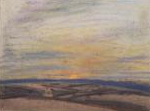

In [ ]:
res = search_df(df, style="Impressionism", genre="landscape", n=5)
display(res)
show_img_url(res.iloc[0]["img"])

In [ ]:
import pandas as pd

path = "second_prompt_dataset_FINAL_genre_styleMacro.csv"
df = pd.read_csv(path)

print("Numero righe:", len(df))
print("Numero colonne:", len(df.columns))

Numero righe: 24231
Numero colonne: 31


In [ ]:
print("Colonne presenti:")
for col in df.columns:
    print("-", col)

Colonne presenti:
- i
- true_artist
- file_name_x
- img_url
- timestamp
- model
- ok
- error
- response_text
- identified
- pred_artist
- pred_title
- confidence
- true_norm
- pred_norm
- true_surname
- pred_surname
- correct_hybrid
- correct_surname_only
- correct_fuzzy
- correct_token_based
- artist
- style_original
- genre
- movement
- tags
- url
- img
- file_name_y
- final_genre
- style_macro


In [ ]:
import pandas as pd

path = "second_prompt_dataset_FINAL_genre_styleMacro.csv"
df = pd.read_csv(path)

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "unique_values": df.nunique()
})

summary = summary.sort_values("unique_values", ascending=False)

summary

,dtype,non_null,null,unique_values
file_name_y,object,52951,0,52951
url,object,52951,0,52951
i,int64,52951,0,52946
timestamp,object,52951,0,52946
img,object,52951,0,52946
file_name_x,object,52951,0,52946
img_url,object,52951,0,52946
response_text,object,51870,1081,47113
pred_title,object,50564,2387,37590
tags,object,34266,18685,17521


In [ ]:
for col in df.columns:
    print("\n==============================")
    print("COLONNA:", col)
    print("Unique values:", df[col].nunique())
    print("Esempi:")
    print(df[col].dropna().astype(str).unique()[:5])


COLONNA: i
Unique values: 52946
Esempi:
['0' '1' '2' '3' '4']

COLONNA: true_artist
Unique values: 2524
Esempi:
['Frank W. Benson' 'Manuela Sambo' 'Walter Battiss' 'Alexander Clarot'
 'Jean-Baptiste van Loo']

COLONNA: file_name_x
Unique values: 52946
Esempi:
['102839-frank-w-benson-river-scene-1921.jpg'
 '248823-badende-nach-tizian-1.jpg' '161158-rock-painting-motif.jpg'
 '39240-s-l1600.jpg'
 '24258-francis-godolphin-2nd-earl-of-godolphin-by-jean-baptiste-van-loo.jpg']

COLONNA: img_url
Unique values: 52946
Esempi:
['https://uploads4.wikiart.org/00191/images/frank-w-benson/frank-w-benson-river-scene-1921.jpg!Large.jpg'
 'https://uploads5.wikiart.org/00138/images/manuela-sambo/badende-nach-tizian-1.jpg!Large.jpg'
 'https://uploads4.wikiart.org/images/walter-battiss/rock-painting-motif.jpg'
 'https://uploads3.wikiart.org/00332/images/alexander-clarot/s-l1600.jpg!Large.jpg'
 'https://uploads8.wikiart.org/00308/images/jean-baptiste-van-loo/francis-godolphin-2nd-earl-of-godolphin-by-jean-

In [ ]:
import pandas as pd

path = "second_prompt_dataset_FINAL_genre_styleMacro.csv"
df = pd.read_csv(path)

cols_keep = [
    "file_name_x",
    "true_artist",
    "pred_artist",
    "style_macro",
    "final_genre",
    "img_url"
]

df_clean = df[cols_keep].copy()

df_clean = df_clean.rename(columns={
    "file_name_x": "image",
    "final_genre": "genre"
})

print("Dataset pronto per secondo prompt")
print("Righe:", len(df_clean))
print("Colonne:", list(df_clean.columns))

df_clean.head()

Dataset pronto per secondo prompt
Righe: 52951
Colonne: ['image', 'true_artist', 'pred_artist', 'style_macro', 'genre', 'img_url']


,image,true_artist,pred_artist,style_macro,genre,img_url
0,102839-frank-w-benson-river-scene-1921.jpg,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,https://uploads4.wikiart.org/00191/images/fran...
1,248823-badende-nach-tizian-1.jpg,Manuela Sambo,Julie Favaloro,Expressionism,portrait,https://uploads5.wikiart.org/00138/images/manu...
2,161158-rock-painting-motif.jpg,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,https://uploads4.wikiart.org/images/walter-bat...
3,39240-s-l1600.jpg,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,https://uploads3.wikiart.org/00332/images/alex...
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,https://uploads8.wikiart.org/00308/images/jean...


In [ ]:
OUT_READY = "/content/wikiart_second_prompt_READY.csv"
df_clean.to_csv(OUT_READY, index=False)

print("Salvato:", OUT_READY)

Salvato: /content/wikiart_second_prompt_READY.csv


In [ ]:
import os, json, time, random
import pandas as pd
from datetime import datetime

#CONFIG
DATASET_NAME = "wikiart"
MODEL_NAME = "models/gemini-2.5-flash"
EXTRACT_DIR = "/content/wikiart_tmp/wikiart/wikiart"

#OUTPUT
OUT_DIR = "/content/wikiart_second_prompt_run"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state.json")
OUT_CSV = os.path.join(OUT_DIR, "results.csv")

#INPUT READY
ready_path = "/content/wikiart_second_prompt_READY.csv"
df_in = pd.read_csv(ready_path)

#image, img_url, true_artist, pred_artist, style_macro, genre
print("Righe input:", len(df_in))
print("Colonne:", list(df_in.columns))

df_in["image_path"] = df_in["image"].apply(lambda x: os.path.join(EXTRACT_DIR, str(x)))

# check
missing = (~df_in["image_path"].apply(os.path.exists)).sum()
print("Immagini mancanti su disco:", missing)

df_in.head()

Righe input: 52951
Colonne: ['image', 'true_artist', 'pred_artist', 'style_macro', 'genre', 'img_url']
Immagini mancanti su disco: 20


,image,true_artist,pred_artist,style_macro,genre,img_url,image_path
0,102839-frank-w-benson-river-scene-1921.jpg,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,https://uploads4.wikiart.org/00191/images/fran...,/content/wikiart_tmp/wikiart/wikiart/102839-fr...
1,248823-badende-nach-tizian-1.jpg,Manuela Sambo,Julie Favaloro,Expressionism,portrait,https://uploads5.wikiart.org/00138/images/manu...,/content/wikiart_tmp/wikiart/wikiart/248823-ba...
2,161158-rock-painting-motif.jpg,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,https://uploads4.wikiart.org/images/walter-bat...,/content/wikiart_tmp/wikiart/wikiart/161158-ro...
3,39240-s-l1600.jpg,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,https://uploads3.wikiart.org/00332/images/alex...,/content/wikiart_tmp/wikiart/wikiart/39240-s-l...
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,https://uploads8.wikiart.org/00308/images/jean...,/content/wikiart_tmp/wikiart/wikiart/24258-fra...


In [ ]:
PROMPT = r"""
You are an art history expert.

Analyze the provided artwork image carefully.

Respond ONLY in valid JSON format.
Do not include explanations outside the JSON.
If unsure, make your best reasoned hypothesis.
If a category does not fit any option, use "Unknown".

Provide:

1) artist_guess:
   - Provide exactly 3 possible artists.
   - Order them from most probable to least probable.

2) macro_style:
   Choose ONLY one from this list:
   [
   "Abstract (large family)",
   "Academic / Traditional",
   "Art Nouveau / Deco",
   "Asian Traditional",
   "Baroque",
   "Constructivist / Geometric Modern",
   "Contemporary Media",
   "Cubism",
   "Expressionism",
   "Feminist / Identity",
   "Futurism",
   "Impressionism",
   "Medieval",
   "Modernism",
   "Muralism",
   "Naturalism / Luminism / Tonalism",
   "Naïve",
   "Neoclassicism / Classicism",
   "Pop / Dada / Postmodern",
   "Realism",
   "Renaissance",
   "Romanticism",
   "Surrealism / Metaphysical",
   "Symbolism / Intimism",
   ]

3) technique:
   Choose ONLY one from:
   [
   "oil",
   "tempera",
   "fresco",
   "drawing",
   "pastel",
   "watercolour",
   "encaustic",
   ]

4) genre:
   Choose ONLY one:
   [
   "historical",
   "interior",
   "landscape",
   "mythological",
   "other",
   "genre"
   "portrait",
   "religious",
   "still-life",
   "study"
   ]

5) school:
   Choose ONLY one:
   [
   "american",
   "austrian",
   "belgian",
   "bohemian",
   "catalan",
   "danish",
   "dutch",
   "english",
   "finnish",
   "flemish",
   "french",
   "german",
   "greek",
   "hungarian",
   "irish",
   "italian",
   "netherlandish",
   "norwegian",
   "other",
   "polish",
   "portuguese",
   "russian",
   "scottish",
   "spanish",
   "swedish",
   "swiss"
   ]

6) historical_period:
   Choose one of these ranges if applicable.
   If clearly before or after, estimate the closest period.

   [
   "0751-0800","0801-0850","0851-0900","0951-1000",
   "1001-1050","1051-1100","1101-1150","1151-1200",
   "1201-1250","1251-1300","1301-1350","1351-1400",
   "1401-1450","1451-1500","1501-1550","1551-1600",
   "1601-1650","1651-1700","1701-1750","1751-1800",
   "1801-1850","1851-1900"
   ]

7) wolfflin_principles:

For each pair, rate the artwork on a scale from 1 to 5.

Use this scale for ALL pairs:

1 = Clearly first pole
2 = Mostly first pole
3 = Balanced / Borderline
4 = Mostly second pole
5 = Clearly second pole

Respond ONLY with an integer from 1 to 5 for each pair.

Pairs:

- linear_vs_painterly
  (1 = clearly linear, 5 = clearly painterly)

- plane_vs_recession
  (1 = clearly planar, 5 = clearly recessional)

- closed_vs_open_form
  (1 = clearly closed form, 5 = clearly open form)

- multiplicity_vs_unity
  (1 = clearly multiplicity, 5 = clearly unity)

- absolute_vs_relative_clarity
  (1 = clearly absolute clarity, 5 = clearly relative clarity)

8) short_description:
   Provide a brief (max 80 words) objective description of what is visible in the artwork.

Return strictly this JSON structure:

{
  "artist_guess": ["Name1", "Name2", "Name3"],
  "macro_style": "...",
  "technique": "...",
  "genre": "...",
  "school": "...",
  "historical_period": "...",
  "wolfflin_principles": {
      "linear_vs_painterly": "...",
      "plane_vs_recession": "...",
      "closed_vs_open_form": "...",
      "multiplicity_vs_unity": "...",
      "absolute_vs_relative_clarity": "..."
  },
  "short_description": "..."
}
"""

In [ ]:
# BOOT UNICO
import os, json, time, random, math, re
import requests
from datetime import datetime, timezone
from google import genai
from google.genai import types

# client
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# bytes immagine
def get_image_bytes(image_path, img_url=None, timeout=20):
    if image_path and os.path.exists(image_path):
        with open(image_path, "rb") as f:
            return f.read()

    if img_url and str(img_url).strip().lower() not in ["nan", "none", ""]:
        r = requests.get(img_url, timeout=timeout)
        r.raise_for_status()
        return r.content

    raise FileNotFoundError(f"Missing image file and no valid img_url. path={image_path} url={img_url}")


def _mime_from_path(p):
    p = str(p).lower()
    if p.endswith(".png") or ".png" in p:
        return "image/png"
    return "image/jpeg"


# JSON extractor
def _extract_json(text: str):
    if not text:
        raise ValueError("Empty response text")

    t = text.strip()
    t = re.sub(r"^```json\s*", "", t)
    t = re.sub(r"^```\s*", "", t)
    t = re.sub(r"\s*```$", "", t).strip()

    #parsing diretto
    try:
        return json.loads(t)
    except:
        pass
    m = re.search(r"\{.*\}", t, flags=re.DOTALL)
    if m:
        return json.loads(m.group(0))

    raise ValueError("No JSON object found in response")

print("BOOT OK:",
      "client" in globals(),
      "PROMPT" in globals(),
      "get_image_bytes" in globals(),
      "call_gemini_bytes" in globals())

BOOT OK: True True True True


In [ ]:
import json, re
from google.genai import types

def _extract_json(text: str):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()
    t = re.sub(r"^```json\s*", "", t)
    t = re.sub(r"^```\s*", "", t)
    t = re.sub(r"\s*```$", "", t).strip()

    # parsing diretto
    try:
        return json.loads(t)
    except:
        pass
    m = re.search(r"\{.*\}", t, flags=re.DOTALL)
    if m:
        return json.loads(m.group(0))

    raise ValueError("NO_JSON_FOUND_IN_RESPONSE")

def _get_text_from_resp(resp):
    # resp.text
    t = getattr(resp, "text", None)
    if t:
        return t

    # candidates/parts
    cands = getattr(resp, "candidates", None) or []
    if cands:
        content = getattr(cands[0], "content", None)
        parts = getattr(content, "parts", None) or []
        for p in parts:
            pt = getattr(p, "text", None)
            if pt:
                return pt

    # blocco safety o risposta vuota
    raise ValueError("EMPTY_OR_BLOCKED_RESPONSE")

def call_gemini_bytes(img_bytes, mime="image/jpeg", prompt_text=None):
    if prompt_text is None:
        prompt_text = PROMPT

    parts = [
        types.Part.from_text(text=prompt_text),
        types.Part.from_bytes(data=img_bytes, mime_type=mime),
    ]

    resp = client.models.generate_content(
        model=MODEL_NAME,
        contents=parts,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.2,
        )
    )

    text = _get_text_from_resp(resp)
    return _extract_json(text)

In [ ]:
import inspect
src = inspect.getsource(call_gemini_bytes)
print("FORZA JSON?", "response_mime_type" in src)
print(src[:400])

FORZA JSON? True
def call_gemini_bytes(img_bytes, mime="image/jpeg", prompt_text=None):
    if prompt_text is None:
        prompt_text = PROMPT

    parts = [
        types.Part.from_text(text=prompt_text),
        types.Part.from_bytes(data=img_bytes, mime_type=mime),
    ]

    resp = client.models.generate_content(
        model=MODEL_NAME,
        contents=parts,
        config=types.GenerateContentConfig(
  


In [ ]:
def get_done_images_from_jsonl(path):
    done = set()
    bad_pred = 0
    if not os.path.exists(path):
        return done

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is not True:
                    continue

                pred = rec.get("pred")
                # giusto solo dict con chiavi attese
                if isinstance(pred, dict) and "artist_guess" in pred and "macro_style" in pred:
                    done.add(rec.get("image"))
                else:
                    bad_pred += 1
            except:
                pass

    print("done_images validi:", len(done))
    print("ok:true ma pred NON strutturato (da rifare):", bad_pred)
    return done

done_images = get_done_images_from_jsonl(OUT_JSONL)

state = {
    "dataset": DATASET_NAME,
    "model": MODEL_NAME,
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
    "done_count": len(done_images),
}
with open(STATE_JSON, "w", encoding="utf-8") as f:
    json.dump(state, f, ensure_ascii=False, indent=2)

print("Gia analizzate (buone):", len(done_images))

done_images validi: 6278
ok:true ma pred NON strutturato (da rifare): 0
Gia analizzate (buone): 6278


In [ ]:
from datetime import datetime, timezone
import math, time, random, json

RPM_TARGET = 120
MIN_SECONDS = 0.6

N_OPERE = 8000
SAVE_STATE_EVERY = 10

processed_ok = 0
processed_err = 0

def _safe_url(x):
    if x is None:
        return None
    if isinstance(x, float) and math.isnan(x):
        return None
    s = str(x).strip()
    return s if s and s.lower() != "nan" else None

def _mime_from_path(p):
    p = str(p).lower()
    if p.endswith(".png") or ".png" in p:
        return "image/png"
    return "image/jpeg"

def backoff_sleep(err_msg, base=0.6):
    msg = (err_msg or "").lower()
    if "429" in msg or "resource_exhausted" in msg or "rate" in msg:
        time.sleep(20 + random.uniform(0, 5))
    else:
        time.sleep(base + random.uniform(0, 0.25))

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_in.head(N_OPERE).iterrows():
        image = row["image"]
        image_path = row["image_path"]
        img_url = _safe_url(row.get("img_url"))

        if image in done_images:
            continue

        rec = {
            "dataset": DATASET_NAME,
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),

            "image": image,
            "image_path": image_path,
            "img_url": img_url,

            "true_artist": row.get("true_artist"),
            "pred_artist_firstprompt": row.get("pred_artist"),
            "true_style_macro": row.get("style_macro"),
            "true_genre": row.get("genre"),

            "pred": None,
            "ok": False,
            "error": None,
        }

        try:

            img_bytes = get_image_bytes(image_path, img_url)

            mime = _mime_from_path(image_path)

            # call Gemini
            pred = call_gemini_bytes(img_bytes, mime=mime)

            rec["pred"] = pred
            rec["ok"] = True

            processed_ok += 1
            done_images.add(image)

        except Exception as e:
            rec["error"] = str(e)
            processed_err += 1


        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            state = {
                "dataset": DATASET_NAME,
                "model": MODEL_NAME,
                "updated_at_utc": datetime.now(timezone.utc).isoformat(),
                "done_count": len(done_images),
                "processed_ok": processed_ok,
                "processed_err": processed_err,
                "last_image": image,
            }
            with open(STATE_JSON, "w", encoding="utf-8") as f:
                json.dump(state, f, ensure_ascii=False, indent=2)

            print("Progress:", processed_ok, "ok |", processed_err, "err | done:", len(done_images))

        backoff_sleep(rec.get("error"), base=MIN_SECONDS)

print("FINITO. OK:", processed_ok, "| ERR:", processed_err)

Progress: 0 ok | 10 err | done: 7247
Progress: 0 ok | 20 err | done: 7247
Progress: 0 ok | 30 err | done: 7247
Progress: 1 ok | 39 err | done: 7248
Progress: 11 ok | 39 err | done: 7258
Progress: 21 ok | 39 err | done: 7268
Progress: 31 ok | 39 err | done: 7278
Progress: 41 ok | 39 err | done: 7288
Progress: 51 ok | 39 err | done: 7298
Progress: 61 ok | 39 err | done: 7308
Progress: 71 ok | 39 err | done: 7318
Progress: 81 ok | 39 err | done: 7328
Progress: 91 ok | 39 err | done: 7338
Progress: 101 ok | 39 err | done: 7348
Progress: 111 ok | 39 err | done: 7358
Progress: 121 ok | 39 err | done: 7368
Progress: 131 ok | 39 err | done: 7378
Progress: 141 ok | 39 err | done: 7388
Progress: 151 ok | 39 err | done: 7398
Progress: 161 ok | 39 err | done: 7408
Progress: 171 ok | 39 err | done: 7418
Progress: 180 ok | 40 err | done: 7427
Progress: 190 ok | 40 err | done: 7437
Progress: 200 ok | 40 err | done: 7447
Progress: 210 ok | 40 err | done: 7457
Progress: 220 ok | 40 err | done: 7467
Pro

KeyboardInterrupt: 

In [ ]:
import os, json, re
from datetime import datetime

JSONL_PATH = OUT_JSONL
LAST_N = 25

def _tail_lines(path, n=50):
    if not os.path.exists(path):
        print("File non trovato:", path)
        return []
    with open(path, "rb") as f:
        f.seek(0, 2)
        end = f.tell()
        size = 0
        block = 4096
        data = b""
        while end > 0 and data.count(b"\n") <= n:
            step = min(block, end)
            end -= step
            f.seek(end)
            data = f.read(step) + data
        lines = data.splitlines()[-n:]
    return [l.decode("utf-8", errors="replace") for l in lines]

def summarize_pred(pred):
    """ritorna (is_dict, keys, missing)"""
    expected = ["artist_guess","macro_style","technique","genre","school","historical_period","wolfflin_principles","short_description"]
    if isinstance(pred, dict):
        keys = list(pred.keys())
        missing = [k for k in expected if k not in pred]
        return True, keys, missing
    elif isinstance(pred, str):
        return False, ["<STRING>"], expected
    else:
        return False, [f"<{type(pred).__name__}>"], expected

lines = _tail_lines(JSONL_PATH, LAST_N)
print("=== FILE ===")
print("Path:", JSONL_PATH)
print("Ultime righe lette:", len(lines))

ok_count = 0
structured_ok = 0
empty_resp = 0

print("\n=== ULTIME OPERE ===")
for i, line in enumerate(lines, 1):
    try:
        rec = json.loads(line)
    except Exception as e:
        print(f"[{i}] Riga NON parseabile:", str(e))
        print("  snippet:", line[:200])
        continue

    img = rec.get("image")
    ok = rec.get("ok")
    err = rec.get("error")
    pred = rec.get("pred")

    if ok is True:
        ok_count += 1

    is_dict, keys, missing = summarize_pred(pred)
    if ok is True and is_dict and ("artist_guess" in pred) and ("macro_style" in pred):
        structured_ok += 1

    # conta errori vuoti
    if isinstance(err, str) and ("Empty response" in err or "NoneType" in err):
        empty_resp += 1

    print(f"\n[{i}] image: {img}")
    print("  ok:", ok)
    if err:
        print("  error:", err[:160])
    print("  pred_type:", type(pred).__name__)
    print("  pred_keys:", keys[:12])
    if is_dict and missing:
        print("  missing:", missing)

print("\n=== RIASSUNTO ===")
print("ok=True nelle ultime:", ok_count)
print("ok=True e pred JSON strutturato:", structured_ok)
print("error vuoto/NoneType nelle ultime:", empty_resp)

=== FILE ===
Path: /content/wikiart_second_prompt_run/results.jsonl
Ultime righe lette: 25

=== ULTIME OPERE ===

[1] image: 162956-feuilles-i-1967.jpg
  ok: True
  pred_type: dict
  pred_keys: ['artist_guess', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'wolfflin_principles', 'short_description']

[2] image: 88771-cloches-du-soir.jpg
  ok: True
  pred_type: dict
  pred_keys: ['artist_guess', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'wolfflin_principles', 'short_description']

[3] image: 58932-portrait-angiolina.jpg
  ok: True
  pred_type: dict
  pred_keys: ['artist_guess', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'wolfflin_principles', 'short_description']

[4] image: 71455-60340b1aedc2c90fc86e7fb9.jpg
  ok: True
  pred_type: dict
  pred_keys: ['artist_guess', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'wolfflin_principles', 'short_description']

[5] image: 233168-vermillion-diary-no

In [ ]:
import os, json
from datetime import datetime

IN_JSONL = OUT_JSONL
CLEAN_JSONL = OUT_JSONL.replace(".jsonl", "_CLEAN.jsonl")

def is_good(rec):
    if rec.get("ok") is not True:
        return False
    pred = rec.get("pred")
    if not isinstance(pred, dict):
        return False
    return ("artist_guess" in pred) and ("macro_style" in pred)

# righe parseabili
rows = []
bad_lines = 0
with open(IN_JSONL, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            bad_lines += 1

print("Tot righe parseabili:", len(rows))
print("Righe non parseabili:", bad_lines)

# filtra
good = [r for r in rows if is_good(r)]
print("Righe buone:", len(good))

# dedup per image
by_img = {}
for r in good:
    img = r.get("image")
    if not img:
        continue
    by_img[img] = r

good_dedup = list(by_img.values())
print("Righe buone deduplicate:", len(good_dedup))

# JSONL
with open(CLEAN_JSONL, "w", encoding="utf-8") as f:
    for r in good_dedup:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Salvato JSONL pulito:", CLEAN_JSONL)

Tot righe parseabili: 7580
Righe non parseabili: 0
Righe BUONE: 7539
Righe BUONE deduplicate: 7539
Salvato JSONL pulito: /content/wikiart_second_prompt_run/results_CLEAN.jsonl


In [ ]:
import shutil
shutil.copy2(CLEAN_JSONL, OUT_JSONL)
print("OUT_JSONL sovrascritto con versione pulita.")

OUT_JSONL sovrascritto con versione pulita.


In [ ]:
import json
import pandas as pd

rows = []
bad = 0

with open(OUT_JSONL.replace(".jsonl", "_CLEAN.jsonl"), "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception as e:
            bad += 1
            if bad <= 3:
                print(f"Riga {i} non parseabile:", str(e))
                print("Snippet:", line[:200])

print("Righe lette correttamente:", len(rows))
print("Righe rotte:", bad)

flat = []
for r in rows:
    raw_pred = r.get("pred")

    pred_is_dict = isinstance(raw_pred, dict)
    pred = raw_pred if pred_is_dict else {}
    pred_raw = raw_pred if isinstance(raw_pred, str) else None

    wol = pred.get("wolfflin_principles") or {}
    ag = pred.get("artist_guess") or [None, None, None]

    flat.append({
        "dataset": r.get("dataset"),
        "model": r.get("model"),
        "timestamp_utc": r.get("timestamp_utc"),

        "image": r.get("image"),
        "img_url": r.get("img_url"),

        "true_artist": r.get("true_artist"),
        "pred_artist_firstprompt": r.get("pred_artist_firstprompt"),
        "true_style_macro": r.get("true_style_macro"),
        "true_genre": r.get("true_genre"),

        "artist_guess_1": ag[0] if len(ag) > 0 else None,
        "artist_guess_2": ag[1] if len(ag) > 1 else None,
        "artist_guess_3": ag[2] if len(ag) > 2 else None,

        "macro_style_pred": pred.get("macro_style"),
        "technique_pred": pred.get("technique"),
        "genre_pred": pred.get("genre"),
        "school_pred": pred.get("school"),
        "historical_period_pred": pred.get("historical_period"),

        "wol_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "wol_plane_vs_recession": wol.get("plane_vs_recession"),
        "wol_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "wol_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "wol_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity"),

        "short_description": pred.get("short_description"),

        # debug / recupero
        "pred_is_structured": pred_is_dict,
        "pred_raw": pred_raw,

        "ok": r.get("ok"),
        "error": r.get("error"),
    })

df_out = pd.DataFrame(flat)
print("Flat records:", len(flat))
print("DF shape (prima dedup):", df_out.shape)


if "image" in df_out.columns:
    df_out = df_out.sort_values("timestamp_utc", na_position="last").drop_duplicates(subset=["image"], keep="last")

print("DF shape (dopo dedup):", df_out.shape)
display(df_out.tail(3))

df_out.to_csv(OUT_CSV, index=False)
print("CSV salvato:", OUT_CSV)

Righe lette correttamente: 7539
Righe rotte: 0
Flat records: 7539
DF shape (prima dedup): (7539, 27)
DF shape (dopo dedup): (7539, 27)


,dataset,model,timestamp_utc,image,img_url,true_artist,pred_artist_firstprompt,true_style_macro,true_genre,artist_guess_1,...,wol_linear_vs_painterly,wol_plane_vs_recession,wol_closed_vs_open_form,wol_multiplicity_vs_unity,wol_absolute_vs_relative_clarity,short_description,pred_is_structured,pred_raw,ok,error
7536,wikiart,models/gemini-2.5-flash,2026-03-04T12:38:46.246740+00:00,227856-deli-2004.jpg,https://uploads8.wikiart.org/images/red-grooms...,Red Grooms,Charles Fazzino,Pop / Dada / Postmodern,genre,Red Grooms,...,1,4,1,1,1,"A vibrant, detailed, and cartoonish 3D mixed-m...",True,None,True,None
7537,wikiart,models/gemini-2.5-flash,2026-03-04T12:39:03.963424+00:00,72080-a-misty-morning.jpg,https://uploads0.wikiart.org/images/james-char...,James Charles,Alfred Sisley,Impressionism,landscape,Alfred Sisley,...,5,5,4,4,4,An Impressionistic landscape painting depicts ...,True,None,True,None
7538,wikiart,models/gemini-2.5-flash,2026-03-04T12:39:11.223798+00:00,66491-1882.jpg,https://uploads8.wikiart.org/00197/images/alek...,Alexei Korzukhin,Alexander Korzukhin,Realism,genre,Alexey Korzukhin,...,1,5,2,4,1,An interior scene depicts a gathering of peopl...,True,None,True,None


CSV salvato: /content/wikiart_second_prompt_run/results.csv


In [ ]:
missing = df_in.loc[~df_in["image_path"].apply(os.path.exists), ["image", "image_path"]].head(30)
print("Esempi mancanti:")
display(missing)

#  colonna img_url
if "img_url" in df_in.columns:
    miss2 = df_in.loc[~df_in["image_path"].apply(os.path.exists), ["image", "img_url"]].head(30)
    print("\nURL per i mancanti (se presenti):")
    display(miss2)
else:
    print("\n Non vedo la colonna 'img_url' nel dataframe.")

Esempi mancanti:


,image,image_path
3705,9537-danaë-1527.jpg,/content/wikiart_tmp/wikiart/wikiart/9537-dana...
9747,117626-geneviève-camax-zoegger-1936.jpg,/content/wikiart_tmp/wikiart/wikiart/117626-ge...
14282,740-the-last-judgement-символы-четырех-царств-...,/content/wikiart_tmp/wikiart/wikiart/740-the-l...
16541,9700-the-trinity-and-mystic-pietà.jpg,/content/wikiart_tmp/wikiart/wikiart/9700-the-...
19411,6996-group-of-angels-from-corrège.jpg,/content/wikiart_tmp/wikiart/wikiart/6996-grou...
19747,3207-pietà.jpg,/content/wikiart_tmp/wikiart/wikiart/3207-piet...
22108,41938-view-from-buda-ferencáros-1843.jpg,/content/wikiart_tmp/wikiart/wikiart/41938-vie...
23195,10690-pietà-1603.jpg,/content/wikiart_tmp/wikiart/wikiart/10690-pie...
24131,7109-the-mérode-altarpiece-the-donors-1428.jpg,/content/wikiart_tmp/wikiart/wikiart/7109-the-...
24957,171159-landscape-with-bridge-at-óbuda-hajógyár...,/content/wikiart_tmp/wikiart/wikiart/171159-la...



URL per i mancanti (se presenti):


,image,img_url
3705,9537-danaë-1527.jpg,https://uploads6.wikiart.org/images/mabuse/dan...
9747,117626-geneviève-camax-zoegger-1936.jpg,https://uploads6.wikiart.org/images/suzanne-va...
14282,740-the-last-judgement-символы-четырех-царств-...,https://uploads4.wikiart.org/images/andrei-rub...
16541,9700-the-trinity-and-mystic-pietà.jpg,https://uploads3.wikiart.org/images/hans-baldu...
19411,6996-group-of-angels-from-corrège.jpg,https://uploads8.wikiart.org/images/correggio/...
19747,3207-pietà.jpg,https://uploads7.wikiart.org/images/filippo-li...
22108,41938-view-from-buda-ferencáros-1843.jpg,https://uploads6.wikiart.org/images/rudolf-von...
23195,10690-pietà-1603.jpg,https://uploads7.wikiart.org/images/annibale-c...
24131,7109-the-mérode-altarpiece-the-donors-1428.jpg,https://uploads4.wikiart.org/images/robert-cam...
24957,171159-landscape-with-bridge-at-óbuda-hajógyár...,https://uploads1.wikiart.org/images/laszlo-moh...


In [ ]:
import json, os

print("OUT_JSONL:", OUT_JSONL)
print("Esiste:", os.path.exists(OUT_JSONL), "size:", os.path.getsize(OUT_JSONL) if os.path.exists(OUT_JSONL) else None)

last = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            last.append(json.loads(line))
last15 = last[-15:]

for i, rec in enumerate(last15, 1):
    print("\n----", i, "----")
    print("image:", rec.get("image"))
    print("ok:", rec.get("ok"))
    print("error:", rec.get("error"))

OUT_JSONL: /content/wikiart_second_prompt_run/results.jsonl
Esiste: True size: 4575561

---- 1 ----
image: 175624-pilar-1955.jpg
ok: False
error: the JSON object must be str, bytes or bytearray, not NoneType

---- 2 ----
image: 135693-the-cat-in-the-mirror.jpg
ok: False
error: the JSON object must be str, bytes or bytearray, not NoneType

---- 3 ----
image: 244086-goldilock-s-holiday.jpg
ok: False
error: the JSON object must be str, bytes or bytearray, not NoneType

---- 4 ----
image: 178123-between-acts.jpeg!Large.jpeg
ok: False
error: Empty response text

---- 5 ----
image: 158074-two-nudes.jpg
ok: False
error: Empty response text

---- 6 ----
image: 238889-nude-and-african-drum-2006.jpg
ok: False
error: Empty response text

---- 7 ----
image: 185698-sukirah-1977.jpg
ok: False
error: Empty response text

---- 8 ----
image: 10314-bacchus-venus-and-cupid-1595.jpg
ok: False
error: Empty response text

---- 9 ----
image: 135546-three-nude-women-1934.jpg
ok: False
error: Empty response te